# Final Project: Oject Detection with Google's API for Vision
**Class:** I&C SCI X427.08<br>
**Semester:** Summer 2025<br>
**Instructor:** Majed Al Ghandour<br>
**Student:** Richard Hemphill<br>
**DCE ID:** 000970505<br>
**Team:** 2

## Instructions
For the lab, you will work with Google's API for Vision, using several images for training and analysis. You will also use Python Colab to process image detection, classification and label them.

Follow the steps below to set up your Colab notebook for your lab, which will allow you to have your own copy of the lab to work from.

*   Save a copy in your Drive by selecting “File” and then “Save a copy in Drive.”
*   Name your file as YourLastName_FirstName_FinalProject.

**Submission:** Download as the .ipynb format and submit through canvas.

## Credentials
### **Step 1:** Authenticate the API requests by creating a service, then create credentials to authenticate as the service account by downloading a JSON file.

In [1]:
# setup environment
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"]="./uci-dce-514260e9a126.json"

## Libraries
### **Step 2:** Install the client library in python Colab.

>Colab does not import Vision from Google Cloud.  Therefore, the notebook is run with VS Code with local install of Python 3.13.

In [2]:
!pip install --user --upgrade google-cloud-vision --quiet
!pip install --user --upgrade google-cloud-storage --quiet

### **Step 3:** Import the vision library into your Python Colab.

In [3]:
from google.cloud import vision
from google.cloud import storage

### Other Python Libraries

In [4]:
import os
import random
from io import BytesIO
import yaml
from PIL import Image
from PIL import ImageDraw
from IPython.display import display

## Dataset
### **Step 4:** Search and select any two industry sectors you like for object detection.

>Only using a dataset with images from 1 sector (instead of 2). Otherwise, for Object Detection, the meta data of class/location will have to be manipulated for an integrated set.

### **Step 5:** Load your local image files into Python Colab or load them into your Google bucket (recommended), and then link to the URL reference:

>https://public.roboflow.com/object-detection/vehicles-openimages/1

In [5]:
# access dataset from GCP bucket
client = storage.Client()
bucket_name = 'bucket-uci-dce'
bucket = client.get_bucket(bucket_name)

In [6]:
folder_prefix = 'Vehicles-OpenImages-1/'
blobs = bucket.list_blobs(prefix=folder_prefix)

In [7]:
def blobs_to_uri_list(blobs):
    uri_list = []
    for blob in blobs:
        uri_list.append(f'gs://{bucket_name}/{blob.name}')
    return uri_list

In [8]:
# path to the data.yaml file and train/test files
yaml_file = bucket.get_blob(folder_prefix + 'data.yaml').download_as_text()
train_image_files = blobs_to_uri_list(bucket.list_blobs(prefix=folder_prefix + 'train/images/'))
train_label_files = blobs_to_uri_list(bucket.list_blobs(prefix=folder_prefix + 'train/labels/'))
test_image_files = blobs_to_uri_list(bucket.list_blobs(prefix=folder_prefix + 'test/images/'))
test_label_files = blobs_to_uri_list(bucket.list_blobs(prefix=folder_prefix + 'test/labels/'))

### **Step 6:** Train the model and detect your objects.

### Train

>Google Vision API has already been trained and was unable to find a way to perform any custom training.  The following link lists all of the object classes that Vision API can detect.

### **Step 7:** Test and predict objects for two images from the training set. Test and predict objects for an image from the testing set.

### Test Functions

In [9]:
# send image to Vision API processing
def localize_objects(image_uri):
    # Initialize a Vision API client
    client = vision.ImageAnnotatorClient()
    
    # Prepare the image
    image = vision.Image()
    image.source.image_uri = image_uri

    # Perform object localization
    objects = client.object_localization(image=image).localized_object_annotations
    
    return objects

In [10]:
# convert Vision API annotations to labels
def open_file_from_uri(uri):
    blob = bucket.blob('/'.join(uri.split('/')[3:]))
    content = blob.download_as_text()
    return content

In [11]:
# convert Vision API annotations to labels
def open_image_from_uri(image_uri):
    # download image from GCS
    storage_client = storage.Client()
    bucket_name = image_uri.split('/')[2]
    blob_name = '/'.join(image_uri.split('/')[3:])
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(blob_name)
    image_data = blob.download_as_bytes()
    
    # convert to PIL image
    image = Image.open(BytesIO(image_data))
    return image

In [12]:
def annotate_image(image_uri, object_annotations):
    # Open the image using Pillow for drawing
    pil_image = open_image_from_uri(image_uri)
    draw = ImageDraw.Draw(pil_image)
    
    # Draw bounding boxes on the image
    for obj in object_annotations:
        # Bounding box coordinates are returned as a normalized vertex list
        vertices = obj.bounding_poly.normalized_vertices
        
        # Scale coordinates back to image dimensions
        img_width, img_height = pil_image.size
        box = [(vertex.x * img_width, vertex.y * img_height) for vertex in vertices]
    
        # Draw the rectangle
        draw.polygon(box, outline="red", width=2) 
        
        # Add object label (optional)
        draw.text((box[0][0], box[0][1] - 10), obj.name, fill="red")
        
    # display the image with bounding boxes
    display(pil_image)

In [13]:
# print vertices of detected objects
def print_vertices(object_annotations):
    print(f"Number of objects found: {len(object_annotations)}")
    for object_ in object_annotations:
        print(f"\n{object_.name} (confidence: {object_.score})")
        print("Normalized bounding polygon vertices: ")
        for vertex in object_.bounding_poly.normalized_vertices:
            print(f" - ({vertex.x}, {vertex.y})")

In [14]:
# convert YOLO format to bounding box format
def convert_to_bounding_box(label):
    # initialize list to hold bounding boxes
    boxes = []
    
    # parse the label line
    parts = list(map(float, label.strip().split()))
        
    # convert class ID to int
    class_id = int(parts[0])
    
    # YOLO format is center_x, center_y, width, height (normalized)
    center_x, center_y, width, height = parts[1:]
    
    # convert to x_min, y_min, x_max, y_max (normalized)
    x_min = center_x - width / 2
    y_min = center_y - height / 2
    x_max = center_x + width / 2
    y_max = center_y + height / 2
    
    # append the bounding box to the list
    boxes.append({'class_id': class_id, 'box': (x_min, y_min, x_max, y_max)})

    return boxes

In [15]:
# parse YOLO format label file into bounding boxes
def parse_label_file(label_file):
    # initialize list to hold bounding boxes
    boxes = []
    
    # read the label file from GCS
    labels = open_file_from_uri(label_file).splitlines()
    
    # iterate through each line in the label file
    for label in labels:
        boxes.append(convert_to_bounding_box(label))
        
    return boxes

In [16]:
# gets class names from YAML file
def get_class_names(yaml_file):
    yaml_data = yaml.safe_load(yaml_file)
    return yaml_data['names']

In [17]:
# get enum from annotation
def get_enum_from_annotation(object_annotation, yaml_filepath):
    class_names = get_class_names(yaml_file)
    for index, name in enumerate(class_names):
        if name.lower() == object_annotation.name.lower():
            return index
    return None

In [18]:
# convert annotation to label in YOLO format
def convert_annotation_to_label(object_annotation, yaml_file):
    # class name enumeration
    class_enum_value = get_enum_from_annotation(object_annotation, yaml_file)
    
    # bounding box
    box_vertices = object_annotation.bounding_poly.normalized_vertices
    bbox = (box_vertices[0].x, box_vertices[0].y, box_vertices[2].x, box_vertices[2].y)
    
    # create the label
    if class_enum_value is not None and bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        label = f"{class_enum_value} {x_min} {y_min} {x_max} {y_max}"
        return label
    else:
        return None

In [19]:
# convert list of annotations to YOLO labels
def convert_annotations_to_labels(object_annotations, yaml_file):
    yolo_labels = []
    for annotation in object_annotations:
        yolo_label = convert_annotation_to_label(annotation, yaml_file)
        if yolo_label:
            yolo_labels.append(yolo_label)
    return yolo_labels

In [20]:
# calculates the average confidence score from a list of object annotations
def calculate_average_confidence(object_annotations):
    total_confidence = 0
    for annotation in object_annotations:
        total_confidence += annotation.score
    return total_confidence / len(object_annotations) if object_annotations else 0

In [21]:
# convert image to predicted labels
def image_to_predicted_labels(image_path, yaml_file):
    # Get object annotations from Vision API
    object_annotations = localize_objects(image_path)

    # if no objects detected, return empty list
    if not object_annotations:
        return [], 0

    # Convert object annotations to labels
    predicted_labels = convert_annotations_to_labels(object_annotations, yaml_file)
    confidence_score = calculate_average_confidence(object_annotations)

    return predicted_labels, confidence_score

In [22]:
# calculates the Intersection over Union of bounding boxes
def calculate_iou(box1, box2):
    # coordinates of the intersection rectangle
    x_min_inter = max(box1[0], box2[0])
    y_min_inter = max(box1[1], box2[1])
    x_max_inter = min(box1[2], box2[2])
    y_max_inter = min(box1[3], box2[3])

    # area of intersection rectangle
    inter_area = max(0, x_max_inter - x_min_inter) * max(0, y_max_inter - y_min_inter)

    # area of both the prediction and ground-truth rectangles
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # intersection over union
    iou = inter_area / (box1_area + box2_area - inter_area)
    return iou

In [23]:
def parse_label(label):
    # split the label into parts
    parts = list(map(float, label.strip().split()))
    
    # class id
    class_id = int(parts[0])
    
    # bounding box
    x_min = float(parts[1])
    y_min = float(parts[2])
    x_max = float(parts[3])
    y_max = float(parts[4])
    
    return {'class_id': class_id, 'box': (x_min, y_min, x_max, y_max)}

In [24]:
# find best fit predicted label for a given ground truth label
def best_fit_predicted_label(ground_truth_label, predicted_labels):
    # only one ground truth box is expected
    best_iou = 0
    best_fit_predicted_label = None

    # parse predicted labels
    for label in predicted_labels:
        predicted_label= parse_label(label)
        # calculate IoU
        iou = calculate_iou(ground_truth_label['box'], predicted_label['box'])
        # only consider bounding boxes with more than 50% overlap
        if iou > 0.5:
            # find best IoU
            if iou > best_iou:
                best_iou = iou
                best_fit_predicted_label = predicted_label
                
    return best_fit_predicted_label, best_iou

In [25]:
# calculate average precision from precision and recall lists
def calculate_average_precision(precision_list, recall_list):
    # add sentinel values
    recall_list = [0.] + recall_list + [1.]
    precision_list = [1.] + precision_list + [0.]

    # interpolate precision
    for i in range(len(precision_list) - 1, 0, -1):
        precision_list[i - 1] = max(precision_list[i - 1], precision_list[i])

    # calculate AP by summing area under the curve
    ap = 0.0
    for i in range(len(recall_list) - 1):
        ap += (recall_list[i + 1] - recall_list[i]) * precision_list[i + 1]

    return ap

In [26]:
def object_detection_metrics(ground_truth_labels, predicted_labels):
    # initialize
    ious = []
    true_positives = 0
    false_positives = 0
    false_negatives = 0
    precision_points = []
    recall_points = []
    
    # evaluate each ground truth label
    for gt_label in ground_truth_labels:
        # get dict from list
        ground_truth_label = gt_label[0]
        
        # find best fit predicted label
        predicted_label, iou = best_fit_predicted_label(ground_truth_label, predicted_labels)

        # collect metrics
        if predicted_label is not None:
            if predicted_label['class_id'] == ground_truth_label['class_id']:
                # accurate prediction
                ious.append(iou)
                true_positives += 1
            else:
                # incorrect class
                false_negatives += 1
        else:
            # no prediction
            false_negatives += 1
            
        # number of false positives is total predictions minus true positives
        false_positives = len(predicted_labels) - true_positives
        
        # Calculate precision and recall at this point
        current_precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        current_recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        precision_points.append(current_precision)
        recall_points.append(current_recall)

    
    # calculate metrics
    avg_iou = sum(ious) / len(ious) if ious else 0
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    average_precision = calculate_average_precision(precision_points, recall_points)
    
    return {
        'iou': avg_iou,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'average_precision': average_precision
    }

In [27]:
# evaluate object detection by comparing ground truth labels with predicted labels
def evaluate_object_detection(image_path, label_path, yaml_file):
    ground_truth_labels = parse_label_file(label_path)
    predicted_labels, confidence_score = image_to_predicted_labels(image_path, yaml_file)
    metrics = object_detection_metrics(ground_truth_labels, predicted_labels)
    metrics['confidence_score'] = confidence_score
    return metrics
            

### Predictions

In [28]:
# perform prediction and annotation on a given image
def predict_image(image_uri):
    object_annotations = localize_objects(image_uri)
    annotate_image(image_uri , object_annotations)

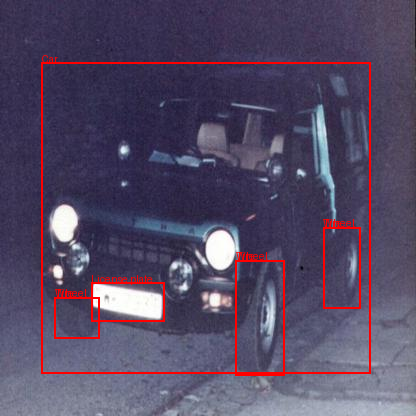

In [29]:
# predict objects from 1st image in training set
predict_image(train_image_files[0])

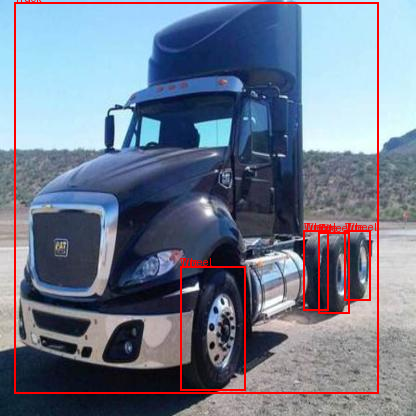

In [30]:
# predict objects from 2nd image in training set
predict_image(train_image_files[1])

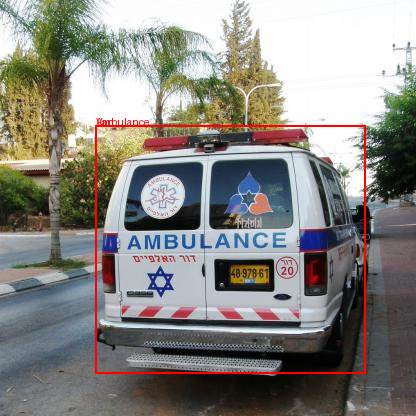

In [31]:
# predict an objects from testing set
predict_image(test_image_files[0])

### Evaluation

In [32]:
# hold scores
iou_scores = []
ap_scores = []
confidence_score = []
recall_scores = []
precision_scores = []
f1_scores = []

# interate through all test files
for image_file, label_file in zip(test_image_files, test_label_files):
    eval_result = evaluate_object_detection(image_file, label_file, yaml_file)
    iou_scores.append(eval_result['iou'])
    ap_scores.append(eval_result['average_precision'])
    confidence_score.append(eval_result['confidence_score'])
    recall_scores.append(eval_result['recall'])
    precision_scores.append(eval_result['precision'])
    f1_scores.append(eval_result['f1_score'])

# accumulate scores
avg_iou = sum(iou_scores) / len(iou_scores) if len(iou_scores) > 0 else 0
map = sum(ap_scores) / len(ap_scores) if len(ap_scores) > 0 else 0
avg_conf = sum(confidence_score) / len(confidence_score) if len(confidence_score) > 0 else 0
avg_recall = sum(recall_scores) / len(recall_scores) if len(recall_scores) > 0 else 0  
avg_precision = sum(precision_scores) / len(precision_scores) if len(precision_scores) > 0 else 0
avg_f1 = sum(f1_scores) / len(f1_scores) if len(f1_scores) > 0 else 0

In [33]:
# print results
print(f"Intersection over Union (IoU): {avg_iou:.4f}")
print(f"Mean Average Precision (mAP): {map:.4f}")
print(f"Confidence Score: {avg_conf:.4f}")
print(f"Recall: {avg_recall:.4f}")
print(f"Precision: {avg_precision:.4f}")
print(f"F1 Score : {avg_f1:.4f}")

Intersection over Union (IoU): 0.7646
Mean Average Precision (mAP): 0.6437
Confidence Score: 0.6750
Recall: 0.7232
Precision: 0.7728
F1 Score : 0.7077
